Strongest feature: X5

Univariate Regression
MSE: 21.680211915802918
R²: 0.7920012396798621

Multivariate Regression
Heating Load MSE: 9.153207645941679
Heating Load R²: 0.9121846294352438
Cooling Load MSE: 9.89342764794407
Cooling Load R²: 0.8932255268607289


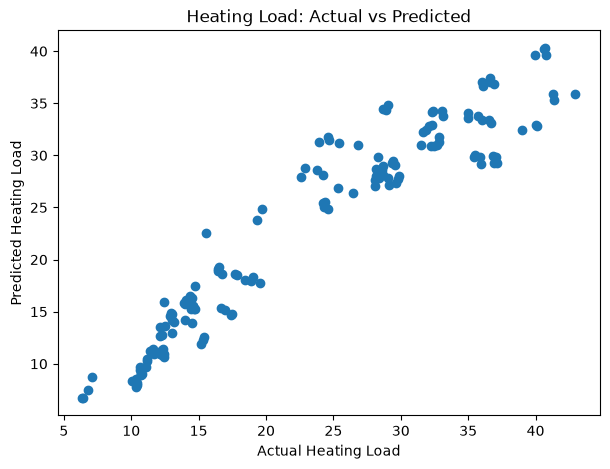

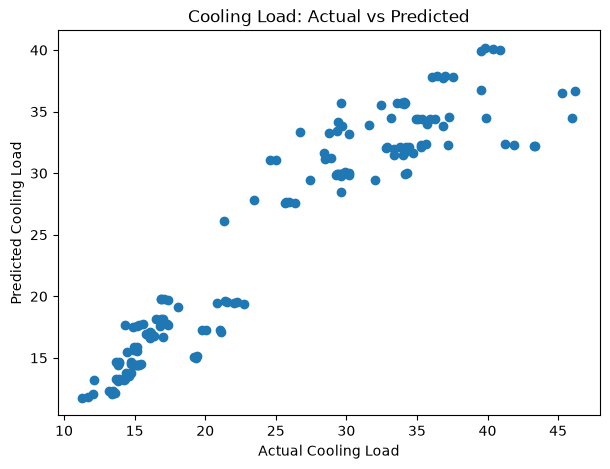

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Objective:
# Predict heating and cooling loads using Linear Regression.

# Load dataset
df = pd.read_excel("Datasets/ENB2012_data.xlsx")
df.columns = df.columns.str.strip()

features = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8"]

# Find strongest feature for Heating Load
correlation = df[features + ["Y1"]].corr()["Y1"].drop("Y1").abs()
strongest = correlation.idxmax()
print("Strongest feature:", strongest)

# Univariate Linear Regression
X = df[[strongest]]
y = df["Y1"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)

print("\nUnivariate Regression")
print("MSE:", mean_squared_error(y_test, prediction))
print("R²:", r2_score(y_test, prediction))

# Multivariate Linear Regression
X = df[features]
y = df[["Y1", "Y2"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)
prediction = model.predict(X_test)

# Evaluate the Heating Load model
heating_mse = mean_squared_error(y_test["Y1"], prediction[:, 0])
heating_r2 = r2_score(y_test["Y1"], prediction[:, 0])

# Evaluate the Cooling Load model
cooling_mse = mean_squared_error(y_test["Y2"], prediction[:, 1])
cooling_r2 = r2_score(y_test["Y2"], prediction[:, 1])

print("\nMultivariate Regression")
print("Heating Load MSE:", heating_mse)
print("Heating Load R²:", heating_r2)
print("Cooling Load MSE:", cooling_mse)
print("Cooling Load R²:", cooling_r2)

# Actual vs Predicted Heating Load
plt.figure(figsize=(7, 5))
plt.scatter(y_test["Y1"], prediction[:, 0])
plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title("Heating Load: Actual vs Predicted")
plt.show()

# Actual vs Predicted Cooling Load
plt.figure(figsize=(7, 5))
plt.scatter(y_test["Y2"], prediction[:, 1])
plt.xlabel("Actual Cooling Load")
plt.ylabel("Predicted Cooling Load")
plt.title("Cooling Load: Actual vs Predicted")
plt.show()